In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("/content/purchase_data.csv", on_bad_lines='skip')
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0.0,3.0,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0.0,12.0,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0.0,12.0,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0.0,8.0,NaN,NaN,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
203277,1001365,P00271142,F,0-17,10,C,3,0.0,5.0,NaN,NaN,5210.0
203278,1001365,P00251242,F,0-17,10,C,3,0.0,5.0,11.0,NaN,5385.0
203279,1001366,P00184942,M,0-17,10,C,0,0.0,1.0,8.0,17.0,15573.0
203280,1001366,P00237642,M,0-17,10,C,0,0.0,5.0,14.0,NaN,5262.0


#EDA
*Checking for null values
*Remove Duplicates
*Remove the outliers
*label enocoding

In [6]:
#checking null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203282 entries, 0 to 203281
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     203282 non-null  int64  
 1   Product_ID                  203282 non-null  object 
 2   Gender                      203282 non-null  object 
 3   Age                         203282 non-null  object 
 4   Occupation                  203282 non-null  int64  
 5   City_Category               203282 non-null  object 
 6   Stay_In_Current_City_Years  203282 non-null  object 
 7   Marital_Status              203281 non-null  float64
 8   Product_Category_1          203281 non-null  float64
 9   Product_Category_2          140237 non-null  float64
 10  Product_Category_3          62257 non-null   float64
 11  Purchase                    203281 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 18.6+ MB


In [7]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,1
Product_Category_1,1
Product_Category_2,63045


In [8]:
df["Product_Category_2"].fillna(0, inplace=True)

In [9]:
df["Product_Category_3"].fillna(0, inplace=True)

In [10]:
df.shape

(203282, 12)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203282 entries, 0 to 203281
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     203282 non-null  int64  
 1   Product_ID                  203282 non-null  object 
 2   Gender                      203282 non-null  object 
 3   Age                         203282 non-null  object 
 4   Occupation                  203282 non-null  int64  
 5   City_Category               203282 non-null  object 
 6   Stay_In_Current_City_Years  203282 non-null  object 
 7   Marital_Status              203281 non-null  float64
 8   Product_Category_1          203281 non-null  float64
 9   Product_Category_2          203282 non-null  float64
 10  Product_Category_3          203282 non-null  float64
 11  Purchase                    203281 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 18.6+ MB


In [12]:
df.isnull().sum().sum()

np.int64(3)

In [13]:
df["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [14]:
#Replacing the age with highest repeating value
df['Age'].fillna(df['Age'].mode()[0])
df['Age'].isnull().sum()

np.int64(0)

In [15]:
df["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [16]:
df["Age"].isnull().sum()

np.int64(0)

In [17]:
#Filliing product id with forwording value
df["Product_ID"].unique()



array(['P00069042', 'P00248942', 'P00087842', ..., 'P00038742',
       'P00261942', 'P00169242'], dtype=object)

In [18]:
df["Product_ID"].isnull().sum()

np.int64(0)

In [19]:
#Filliing product id with forwording value
df["Product_ID"] = df["Product_ID"].fillna(method="ffill")

In [20]:
df["Product_ID"].isnull().sum()

np.int64(0)

In [21]:
#Filliing product id with forwording value
df["Product_ID"].unique()



array(['P00069042', 'P00248942', 'P00087842', ..., 'P00038742',
       'P00261942', 'P00169242'], dtype=object)

In [22]:
# For gender, I am replacing the null value with 'Unknown'
df["Gender"] = df["Gender"].fillna('Unknown')

In [23]:
df["Gender"].isnull().sum()

np.int64(0)

In [24]:
df["Gender"].unique()

array(['F', 'M'], dtype=object)

In [25]:
df.groupby("Gender").size()

,0
Gender,
F,50147
M,153135


In [26]:
#Cleaning the Occupation null
df['Occupation'].fillna(df['Occupation'].mode()[0])

,Occupation
0,10
1,10
2,10
3,10
4,16
...,...
203277,10
203278,10
203279,10
203280,10


In [27]:
df["Occupation"].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [28]:
df["City_Category"].fillna(df["City_Category"].mode()[0])

,City_Category
0,A
1,A
2,A
3,A
4,C
...,...
203277,C
203278,C
203279,C
203280,C


In [29]:
df["City_Category"].unique()

array(['A', 'C', 'B'], dtype=object)

In [30]:
df["Stay_In_Current_City_Years"].fillna(df["Stay_In_Current_City_Years"].mode()[0])

,Stay_In_Current_City_Years
0,2
1,2
2,2
3,2
4,4+
...,...
203277,3
203278,3
203279,0
203280,0


In [31]:
df["Stay_In_Current_City_Years"].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [32]:
#thise to drop row where marital_status is null
#df.dropna(subset=["Marital_Status"],inplace=True)

In [33]:
df.drop("Marital_Status", axis=1, inplace=True)

In [34]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [35]:
df["Product_Category_1"].fillna(df["Product_Category_1"].mode()[0])

,Product_Category_1
0,3.0
1,1.0
2,12.0
3,12.0
4,8.0
...,...
203277,5.0
203278,5.0
203279,1.0
203280,5.0


In [36]:
df["Product_Category_1"].unique()

array([ 3.,  1., 12.,  8.,  5.,  4.,  2.,  6., 14., 11., 13., 15.,  7.,
       16., 18., 10., 17.,  9., nan])

In [37]:
df["Purchase"].unique()

array([ 8370., 15200.,  1422., ...,  6654., 20423.,    nan])

In [38]:
df["Purchase"].fillna(df["Purchase"].mode()[0])

,Purchase
0,8370.0
1,15200.0
2,1422.0
3,1057.0
4,7969.0
...,...
203277,5210.0
203278,5385.0
203279,15573.0
203280,5262.0


In [39]:
df.isnull().sum().sum()

np.int64(2)

In [40]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Product_Category_1,1
Product_Category_2,0
Product_Category_3,0


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203282 entries, 0 to 203281
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     203282 non-null  int64  
 1   Product_ID                  203282 non-null  object 
 2   Gender                      203282 non-null  object 
 3   Age                         203282 non-null  object 
 4   Occupation                  203282 non-null  int64  
 5   City_Category               203282 non-null  object 
 6   Stay_In_Current_City_Years  203282 non-null  object 
 7   Product_Category_1          203281 non-null  float64
 8   Product_Category_2          203282 non-null  float64
 9   Product_Category_3          203282 non-null  float64
 10  Purchase                    203281 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 17.1+ MB


In [43]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '', regex=False)
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].fillna(df['Stay_In_Current_City_Years'].mode()[0])
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)

In [44]:
df["Stay_In_Current_City_Years"].dtype

dtype('int64')

Other thing you want can  do is
#convert cat_2,cat_3 into int  df["Catageroy_2","Catageroy_3"].astype(int)
#dropt the entire row of null df.dropna(inplace=True)
#if you had duplicates ,drop_duplicates(inpalce=True)


<Axes: ylabel='Purchase'>

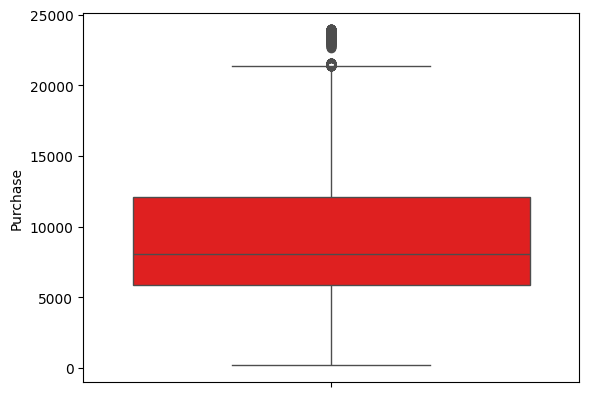

In [45]:
sns.boxplot(y="Purchase",data=df,color="red")

#we know that values outside the lower bound an upperbou cosider as outliers

In [46]:
#Find the outliers
q1=df["Purchase"].quantile(0.25)
q3=df["Purchase"].quantile(0.75)
IQR=q3-q1
Lower_Bound=q1-1.5*IQR
Upper_Bound=q3+1.5*IQR
df=df[(df["Purchase"] >Lower_Bound) &(df["Purchase"] <Upper_Bound)]


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202296 entries, 0 to 203280
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     202296 non-null  int64  
 1   Product_ID                  202296 non-null  object 
 2   Gender                      202296 non-null  object 
 3   Age                         202296 non-null  object 
 4   Occupation                  202296 non-null  int64  
 5   City_Category               202296 non-null  object 
 6   Stay_In_Current_City_Years  202296 non-null  int64  
 7   Product_Category_1          202296 non-null  float64
 8   Product_Category_2          202296 non-null  float64
 9   Product_Category_3          202296 non-null  float64
 10  Purchase                    202296 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 18.5+ MB


In [48]:
263015-261724# gives how many oulliers are present

1291

#"100" ==>100 Type_casting
#green ,red ===> 1,2

In [49]:
#label encoding change the object datatype into numeric
df["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [50]:
#To convert related obeject datatype  into int datatype
from sklearn.preprocessing import LabelEncoder

cols = ["Gender", "Age", "Product_ID", "City_Category"]

le = LabelEncoder()

for i in cols:
    df[i] = le.fit_transform(df[i])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202296 entries, 0 to 203280
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     202296 non-null  int64  
 1   Product_ID                  202296 non-null  int64  
 2   Gender                      202296 non-null  int64  
 3   Age                         202296 non-null  int64  
 4   Occupation                  202296 non-null  int64  
 5   City_Category               202296 non-null  int64  
 6   Stay_In_Current_City_Years  202296 non-null  int64  
 7   Product_Category_1          202296 non-null  float64
 8   Product_Category_2          202296 non-null  float64
 9   Product_Category_3          202296 non-null  float64
 10  Purchase                    202296 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 18.5 MB


In [51]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,640,0,0,10,0,2,3.0,0.0,0.0,8370.0
1,1000001,2280,0,0,10,0,2,1.0,6.0,14.0,15200.0
2,1000001,804,0,0,10,0,2,12.0,0.0,0.0,1422.0
3,1000001,780,0,0,10,0,2,12.0,14.0,0.0,1057.0
4,1000002,2632,1,6,16,2,4,8.0,0.0,0.0,7969.0
...,...,...,...,...,...,...,...,...,...,...,...
203276,1001362,1025,1,3,12,1,0,2.0,17.0,0.0,9956.0
203277,1001365,2493,0,0,10,2,3,5.0,0.0,0.0,5210.0
203278,1001365,2301,0,0,10,2,3,5.0,11.0,0.0,5385.0
203279,1001366,1670,1,0,10,2,0,1.0,8.0,17.0,15573.0


#Avearage Purchase was made by the male betweern 18-25 is 10,000 is still the same
#Null hypo= Avearage Purchase was made by the male betweern 18-25 is 10,000.
#Alternate=Avearage Purchase was made by the male betweern 18-25 is not  10,000
#Steps:
1) Take the sample
2) Creating two hypo
3)select test
4)Compare the p value
if p value>0.05 accpected or else rejected




In [52]:
#Manually checking
aver_Purchase = df[(df["Age"] >= 1) & (df["Gender"] == 1)]["Purchase"].mean()
aver_Purchase


np.float64(9419.105549766378)

In [53]:
filter_data=df[(df["Age"]==1) &(df["Gender"]==1)]
filter_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
97,1000021,2005,1,1,16,1,0,3.0,12.0,0.0,3055.0
98,1000022,3224,1,1,15,0,4,1.0,8.0,17.0,12099.0
99,1000022,1935,1,1,15,0,4,5.0,8.0,0.0,8797.0
100,1000022,1778,1,1,15,0,4,3.0,4.0,0.0,10681.0
101,1000022,1010,1,1,15,0,4,8.0,14.0,0.0,7801.0
...,...,...,...,...,...,...,...,...,...,...,...
203049,1001329,1982,1,1,14,1,3,5.0,0.0,0.0,5369.0
203050,1001329,3100,1,1,14,1,3,5.0,0.0,0.0,3487.0
203141,1001341,306,1,1,7,2,3,5.0,11.0,0.0,8874.0
203142,1001341,1894,1,1,7,2,3,11.0,16.0,0.0,1569.0


In [54]:
sample_data=filter_data.sample(n=3600,random_state=42)
sample_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
114352,1005647,650,1,1,1,2,2,1.0,2.0,16.0,15474.0
158458,1000495,3429,1,1,10,0,1,4.0,5.0,0.0,1439.0
130325,1002015,1739,1,1,4,1,4,5.0,9.0,14.0,1759.0
72892,1005219,1300,1,1,4,1,2,1.0,2.0,0.0,11705.0
124852,1001272,1870,1,1,20,1,0,5.0,0.0,0.0,7095.0
...,...,...,...,...,...,...,...,...,...,...,...
190754,1005482,440,1,1,7,0,1,8.0,0.0,0.0,9986.0
160151,1000777,1886,1,1,19,1,1,6.0,8.0,0.0,12144.0
162742,1001160,2006,1,1,14,2,1,5.0,0.0,0.0,7006.0
60694,1003389,1147,1,1,0,0,0,8.0,14.0,0.0,8042.0


In [55]:
import numpy as np
from scipy.stats import ttest_1samp, shapiro

# Extract the 'Purchase' column from the sample data for the tests
purchase_data_sample = sample_data['Purchase']

# Normality test
'''stat_sample, p_val_shapiro = shapiro(purchase_data_sample)
print("Shapiro p-value:", p_val_shapiro)'''

# T-test with meaningful population mean
t_stat, p_value = ttest_1samp(purchase_data_sample, popmean=10000) # t_stat how away my value present from averaage mean


print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
#in the output i get e-09 means ≈ 8.38 × 10⁻⁹

T-statistic: -7.698338933986378
P-value: 1.768982404856389e-14


#NULL HPOTHISI GOT REJECTED

In [56]:
purchase_data_sample.isnull().sum()

np.int64(0)

#Step 1: Check Normality
#p > 0.05 → OK to use t-test
#p < 0.05 → Data not normal (t-test less reliable)
 No, you do NOT need to multiply by 2
 Because ttest_1samp already gives you a 2-tailed p-value


35percentage of women spending more than 10,000
#NH =Percentage of Women spend more than 35 per
#AH=Percentage of Women spend more than 35 per is not the same


In [57]:
#total purchase of all
df['Purchase'].sum()#242.12 crore #0 is women

np.float64(1871386949.0)

In [58]:
#what is 35 per of money
(2421160721.0)*35/100  #84.74 crore

847406252.35

In [59]:
#Purchase spending by women
df.groupby("Gender")["Purchase"].sum() # 0==>female 56.15 crore

,Purchase
Gender,
0,4.366886e+08
1,1.434698e+09


In [60]:
(df["Gender"]==0).count()

np.int64(202296)

In [61]:
(df["Gender"] == 0).sum() #64243 Women were present # thise is worng

np.int64(49930)

In [62]:
# i have to calculate how members were prsent both amle and female spending more than 35per
(df["Purchase"] > 10000).sum()

np.int64(69410)

In [63]:
women=df[(df["Gender"]==0)&(df["Purchase"]>10000)]

In [64]:
18402/89767

0.20499738211146634

In [65]:
#only 20 per of women is spending more than 1000

In [66]:
#by manual checking we came to know that  reject null hypothises mb
#The next step is take sample size and  find the sutable testing and find the p-value

In [67]:
#For percentage related use Z test

In [68]:
#Fliter women
women = df[df["Gender"] == 0]
women


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,640,0,0,10,0,2,3.0,0.0,0.0,8370.0
1,1000001,2280,0,0,10,0,2,1.0,6.0,14.0,15200.0
2,1000001,804,0,0,10,0,2,12.0,0.0,0.0,1422.0
3,1000001,780,0,0,10,0,2,12.0,14.0,0.0,1057.0
14,1000006,2113,0,5,9,0,1,5.0,8.0,14.0,5378.0
...,...,...,...,...,...,...,...,...,...,...,...
203263,1001361,1141,0,2,0,0,1,1.0,11.0,0.0,15650.0
203264,1001361,1935,0,2,0,0,1,5.0,8.0,0.0,8630.0
203265,1001361,1670,0,2,0,0,1,1.0,8.0,17.0,19339.0
203277,1001365,2493,0,0,10,2,3,5.0,0.0,0.0,5210.0


In [69]:
#Count women spending > 10000
count = (women["Purchase"] > 10000).sum()
count

np.int64(14338)

In [70]:
new=(df["Purchase"] > 10000).sum()


In [71]:
#Step 4: Sample proportion
p_hat = count / new
p_hat

np.float64(0.2065696585506411)

In [72]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(count, new, value=0.35)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: -93.33926711466981
P-value: 0.0


In [73]:
#3333333333
#IS the percentage of men spending more than 10,000 is same for both ages of 18-25 and 26-35

In [74]:
new_1 = df[((df["Age"] == 1) | (df["Age"] == 2))&(df["Gender"]==1) ]
new_1 #116838

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
5,1000003,1754,1,2,15,0,3,1.0,2.0,0.0,15227.0
9,1000005,2529,1,2,20,0,1,8.0,0.0,0.0,7871.0
10,1000005,2301,1,2,20,0,1,5.0,11.0,0.0,5254.0
11,1000005,136,1,2,20,0,1,8.0,0.0,0.0,3957.0
12,1000005,298,1,2,20,0,1,8.0,0.0,0.0,6073.0
...,...,...,...,...,...,...,...,...,...,...,...
203257,1001360,1567,1,2,20,2,1,11.0,15.0,0.0,4443.0
203258,1001360,1304,1,2,20,2,1,1.0,2.0,15.0,7821.0
203259,1001360,2858,1,2,20,2,1,6.0,8.0,10.0,16101.0
203260,1001360,1147,1,2,20,2,1,8.0,14.0,0.0,5852.0


In [75]:
#TOtal men
(df["Gender"] == 1).sum()

np.int64(152366)

In [87]:
#  percentage of men spending 10,000 between 18-15 is:
men_1=((df["Gender"] ==1) & (df["Purchase"]>10000) &(df["Age"] ==1)).sum()
men_1

np.int64(10241)

In [86]:
((df["Gender"] == 1) & (df["Age"] == 1) & (df["Purchase"] > 10000)).sum()

np.int64(10241)

In [82]:
#Step 1: Filter only men
men = df[df["Gender"] == 1]
#Step 2: Split into two age groups
age_18_25 = men[men["Age"] == 1]
age_26_35 = men[men["Age"] == 2]
#Step 3: Count total men in each group
n1 = len(age_18_25)
n2 = len(age_26_35)
#Step 4: Count men spending > 10000
count1 = (age_18_25["Purchase"] > 10000).sum()
count2 = (age_26_35["Purchase"] > 10000).sum()
#Step 5: Calculate percentages
p1 = count1 / n1
p2 = count2 / n2
''' actuallyn doing is p1 =total num of males with age 18-25 purchasing above 10000
divided by all member of males of age 18-25'''

print("18–25:", p1)
print("26–35:", p2)
count1

#Now we test if they are statistically same



18–25: 0.3661946649502968
26–35: 0.36139028475711893


np.int64(10241)

In [81]:
#Step 6: Two-proportion Z-test
from statsmodels.stats.proportion import proportions_ztest

counts = [count1, count2]
nobs = [n1, n2]

stat, p_value = proportions_ztest(counts, nobs)

print("Z-stat:", stat)
print("P-value:", p_value)


Z-stat: 1.3874334323019837
P-value: 0.16530963641708996


Since the p-value (0.1653) is greater than the significance level of 0.05, we fail to reject the null hypothesis. This indicates that there is no statistically significant difference in the proportion of men spending more than 10,000 between the age groups 18–25 and 26–35.